In [ ]:
# ============================================================
# CELL 1 - IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import os
import re
import string
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

In [ ]:
# ============================================================
# CELL 2 - LOAD FAKE NEWS DATASET
# ============================================================

from pandas import read_csv

dataset_path = "/content/Fake_News_Detection_Dataset.csv"

df = read_csv(dataset_path)

print("Dataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Columns:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
display(df.head())

Dataset loaded successfully!

Dataset Shape:
(2000, 4)

Dataset Columns:
['serial_number', 'title', 'text', 'label']

First 5 Records:


,serial_number,title,text,label
0,0,Experts supposedly confirm unbelievable miracl...,An online article makes an extraordinary claim...,0
1,1,New report provides update on transportation,A new report provides an update on transportat...,1
2,2,Shocking secret about secret government plans ...,A viral post claims that a shocking secret abo...,0
3,3,Government announces new health initiative,Officials announced a new initiative related t...,1
4,4,Viral message claims dramatic change in unveri...,A widely shared message claims that a dramatic...,0


In [ ]:
# ============================================================
# CELL 3 - BASIC DATASET INFORMATION
# ============================================================

print("========== DATASET INFORMATION ==========")

print("Total Records:", len(df))
print("Total Columns:", len(df.columns))

print("\nColumn Names:")
for column in df.columns:
    print("-", column)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

========== DATASET INFORMATION ==========
Total Records: 2000
Total Columns: 4

Column Names:
- serial_number
- title
- text
- label

Data Types:
serial_number     int64
title            object
text             object
label             int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   serial_number  2000 non-null   int64 
 1   title          2000 non-null   object
 2   text           2000 non-null   object
 3   label          2000 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 62.6+ KB


In [ ]:
# ============================================================
# CELL 4 - NUMERICAL VS CATEGORICAL FEATURES
# ============================================================

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = df.select_dtypes(
    include=["object"]
).columns

print("Numerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['serial_number', 'label']

Categorical Features:
['title', 'text']


In [ ]:
# ============================================================
# CELL 5 - MISSING VALUE ANALYSIS
# ============================================================

print("========== MISSING VALUE ANALYSIS ==========")

missing_values = df.isnull().sum()

display(missing_values.to_frame("Missing Values"))

print(
    "\nTotal Missing Values:",
    df.isnull().sum().sum()
)

========== MISSING VALUE ANALYSIS ==========


,Missing Values
serial_number,0
title,0
text,0
label,0



Total Missing Values: 0


In [ ]:
# ============================================================
# CELL 6 - DUPLICATE RECORD ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Total Duplicate Records:", duplicate_count)

Total Duplicate Records: 0


In [ ]:
# ============================================================
# CELL 7 - LABEL DISTRIBUTION
# ============================================================

print("========== LABEL DISTRIBUTION ==========")

print(df["label"].value_counts())

print("\nPercentage Distribution:")
print(
    (df["label"].value_counts(normalize=True) * 100)
    .round(2)
)

print("\nUnique Labels:")
print(df["label"].unique())

========== LABEL DISTRIBUTION ==========
label
0    1000
1    1000
Name: count, dtype: int64

Percentage Distribution:
label
0    50.0
1    50.0
Name: proportion, dtype: float64

Unique Labels:
[0 1]


In [ ]:
# ============================================================
# CELL 8 - LABEL MAPPING
# ============================================================

LABEL_NAMES = {
    0: "Fake News",
    1: "Real News"
}

df["News_Type"] = df["label"].map(LABEL_NAMES)

print("Label Mapping:")
print("0 = Fake News")
print("1 = Real News")

print("\nNews Type Distribution:")
print(df["News_Type"].value_counts())

Label Mapping:
0 = Fake News
1 = Real News

News Type Distribution:
News_Type
Fake News    1000
Real News    1000
Name: count, dtype: int64


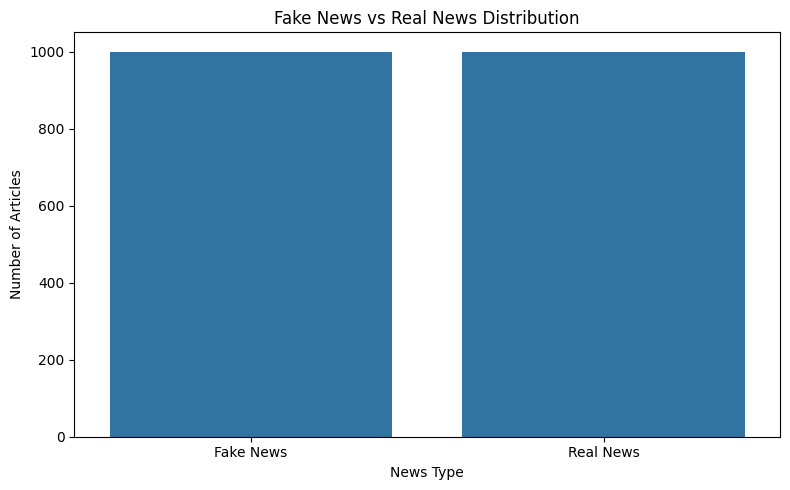

In [ ]:
# ============================================================
# CELL 9 - FAKE VS REAL NEWS DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="News_Type"
)

plt.title("Fake News vs Real News Distribution")
plt.xlabel("News Type")
plt.ylabel("Number of Articles")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 10 - COMBINE TITLE AND ARTICLE TEXT
# ============================================================

# Handle missing values
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")

# Combine title and full article
df["combined_text"] = (
    df["title"].astype(str) + " " +
    df["text"].astype(str)
)

print("Title and article text combined successfully!")

display(
    df[
        ["title", "text", "combined_text", "label"]
    ].head()
)

Title and article text combined successfully!


,title,text,combined_text,label
0,Experts supposedly confirm unbelievable miracl...,An online article makes an extraordinary claim...,Experts supposedly confirm unbelievable miracl...,0
1,New report provides update on transportation,A new report provides an update on transportat...,New report provides update on transportation A...,1
2,Shocking secret about secret government plans ...,A viral post claims that a shocking secret abo...,Shocking secret about secret government plans ...,0
3,Government announces new health initiative,Officials announced a new initiative related t...,Government announces new health initiative Off...,1
4,Viral message claims dramatic change in unveri...,A widely shared message claims that a dramatic...,Viral message claims dramatic change in unveri...,0


In [ ]:
# ============================================================
# CELL 11 - NLP TEXT PREPROCESSING
# ============================================================

import re
import string

def clean_text(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    # Remove HTML tags
    text = re.sub(
        r"<.*?>",
        "",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


# Apply preprocessing
df["clean_text"] = (
    df["combined_text"].apply(clean_text)
)

print("NLP text preprocessing completed!")

display(
    df[
        ["combined_text", "clean_text"]
    ].head()
)

NLP text preprocessing completed!


,combined_text,clean_text
0,Experts supposedly confirm unbelievable miracl...,experts supposedly confirm unbelievable miracl...
1,New report provides update on transportation A...,new report provides update on transportation a...
2,Shocking secret about secret government plans ...,shocking secret about secret government plans ...
3,Government announces new health initiative Off...,government announces new health initiative off...
4,Viral message claims dramatic change in unveri...,viral message claims dramatic change in unveri...


In [ ]:
# ============================================================
# CELL 12 - CREATE TEXT FEATURES
# ============================================================

# Text length
df["TextLength"] = df["clean_text"].apply(
    len
)

# Number of words
df["WordCount"] = df["clean_text"].apply(
    lambda x: len(x.split())
)

# Number of punctuation marks
df["PunctuationCount"] = df["combined_text"].apply(
    lambda x: sum(
        1 for char in str(x)
        if char in string.punctuation
    )
)

# Number of URLs
df["URLCount"] = df["combined_text"].apply(
    lambda x: len(
        re.findall(
            r"http\S+|www\S+|https\S+",
            str(x)
        )
    )
)

# Number of exclamation marks
df["ExclamationCount"] = df["combined_text"].apply(
    lambda x: str(x).count("!")
)

# Number of question marks
df["QuestionCount"] = df["combined_text"].apply(
    lambda x: str(x).count("?")
)

print("Text features created successfully!")

display(
    df[
        [
            "TextLength",
            "WordCount",
            "PunctuationCount",
            "URLCount",
            "ExclamationCount",
            "QuestionCount"
        ]
    ].head()
)

Text features created successfully!


,TextLength,WordCount,PunctuationCount,URLCount,ExclamationCount,QuestionCount
0,316,47,3,0,0,0
1,326,44,5,0,0,0
2,310,48,3,0,0,0
3,314,44,5,0,0,0
4,313,46,3,0,0,0


Text Length Statistics:


,TextLength
count,2000.000000
mean,313.769000
std,12.034868
min,289.000000
25%,305.000000
50%,314.000000
75%,320.000000
max,344.000000



Word Count Statistics:


,WordCount
count,2000.000000
mean,45.689500
std,1.400382
min,44.000000
25%,44.000000
50%,46.000000
75%,46.000000
max,48.000000


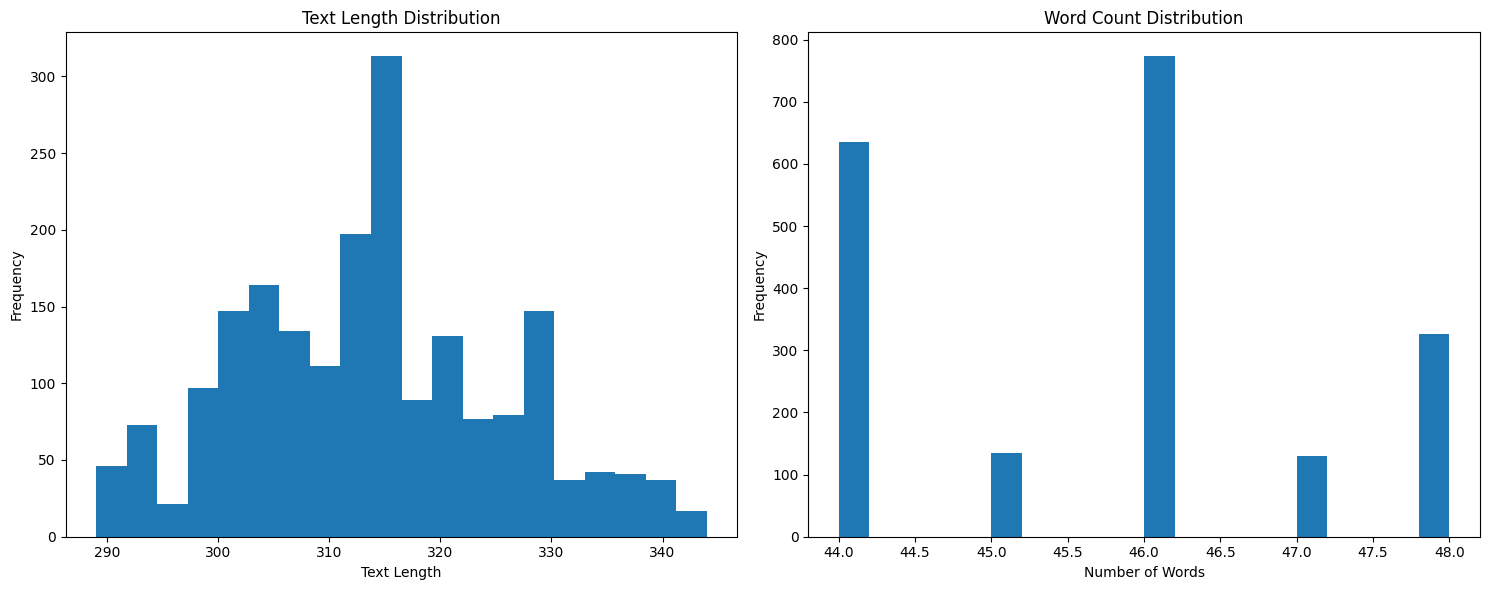

In [ ]:
# ============================================================
# CELL 13 - TEXT LENGTH AND WORD COUNT ANALYSIS
# ============================================================

print("Text Length Statistics:")
display(df["TextLength"].describe())

print("\nWord Count Statistics:")
display(df["WordCount"].describe())


fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

# Text length
axes[0].hist(
    df["TextLength"],
    bins=20
)

axes[0].set_title(
    "Text Length Distribution"
)

axes[0].set_xlabel(
    "Text Length"
)

axes[0].set_ylabel(
    "Frequency"
)


# Word count
axes[1].hist(
    df["WordCount"],
    bins=20
)

axes[1].set_title(
    "Word Count Distribution"
)

axes[1].set_xlabel(
    "Number of Words"
)

axes[1].set_ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()

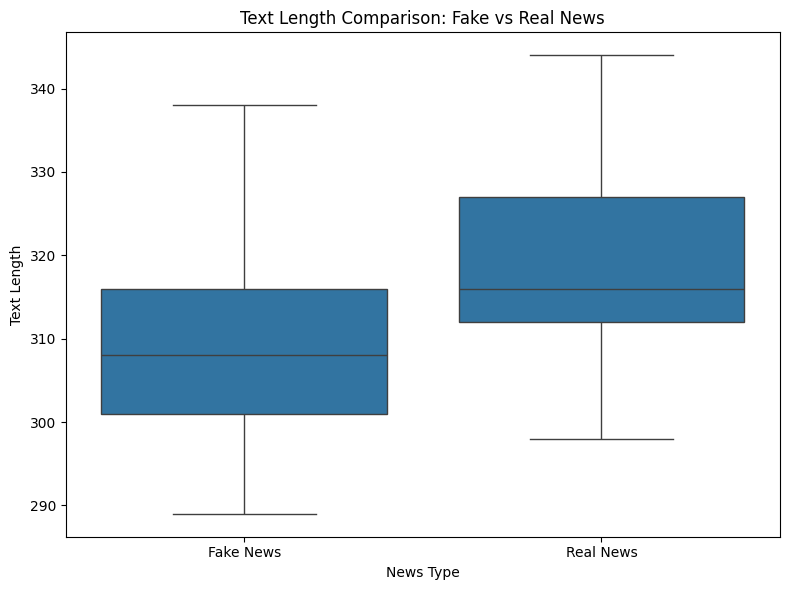

In [ ]:
# ============================================================
# CELL 14 - TEXT LENGTH BY NEWS TYPE
# ============================================================

plt.figure(
    figsize=(8, 6)
)

sns.boxplot(
    data=df,
    x="News_Type",
    y="TextLength"
)

plt.title(
    "Text Length Comparison: Fake vs Real News"
)

plt.xlabel(
    "News Type"
)

plt.ylabel(
    "Text Length"
)

plt.tight_layout()
plt.show()

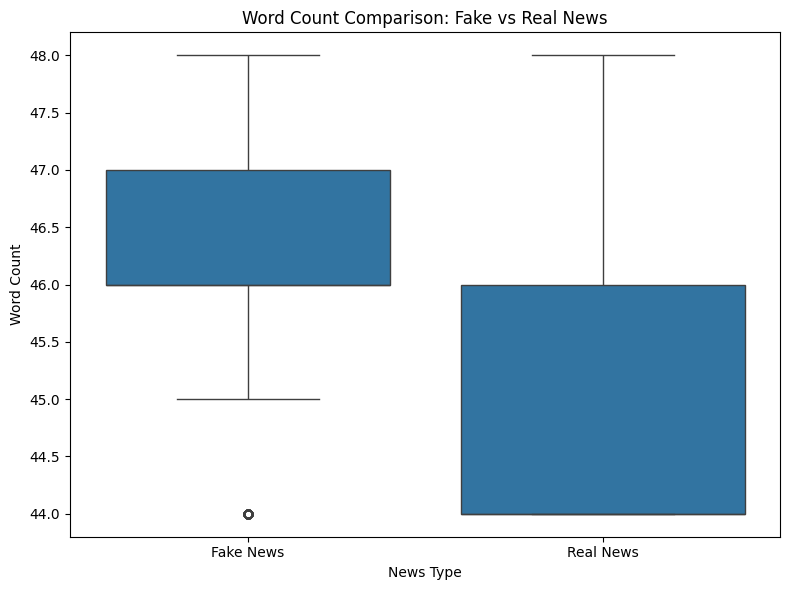

In [ ]:
# ============================================================
# CELL 15 - WORD COUNT BY NEWS TYPE
# ============================================================

plt.figure(
    figsize=(8, 6)
)

sns.boxplot(
    data=df,
    x="News_Type",
    y="WordCount"
)

plt.title(
    "Word Count Comparison: Fake vs Real News"
)

plt.xlabel(
    "News Type"
)

plt.ylabel(
    "Word Count"
)

plt.tight_layout()
plt.show()

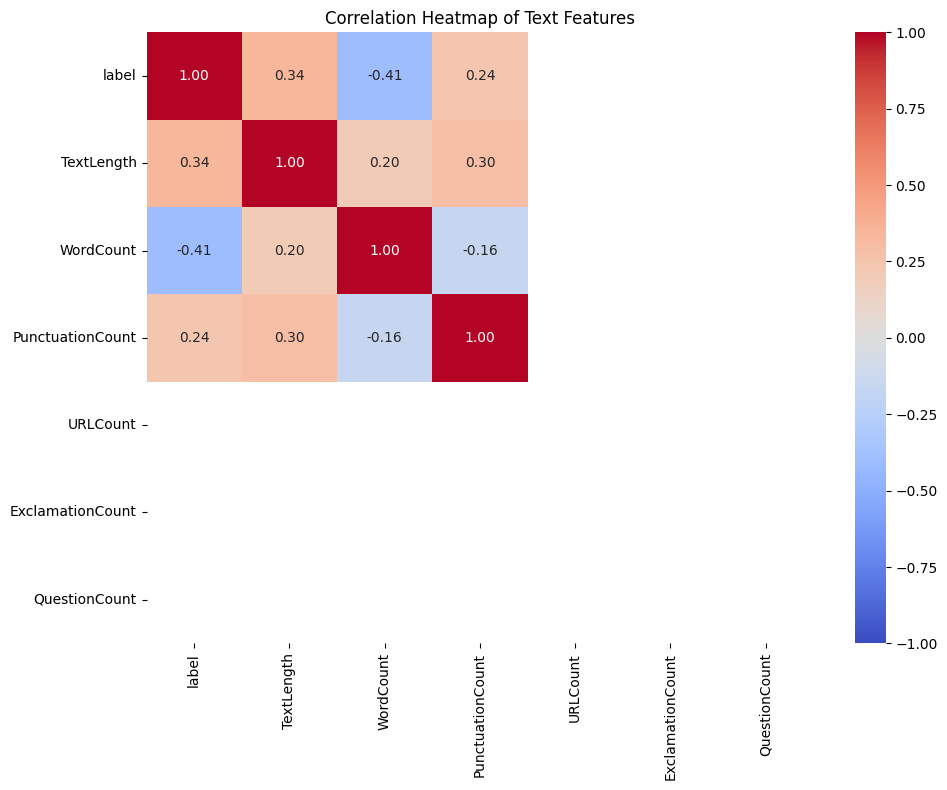

In [ ]:
# ============================================================
# CELL 16 - FEATURE CORRELATION HEATMAP
# ============================================================

correlation_features = [
    "label",
    "TextLength",
    "WordCount",
    "PunctuationCount",
    "URLCount",
    "ExclamationCount",
    "QuestionCount"
]

correlation_matrix = df[
    correlation_features
].corr()

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title(
    "Correlation Heatmap of Text Features"
)

plt.tight_layout()
plt.show()

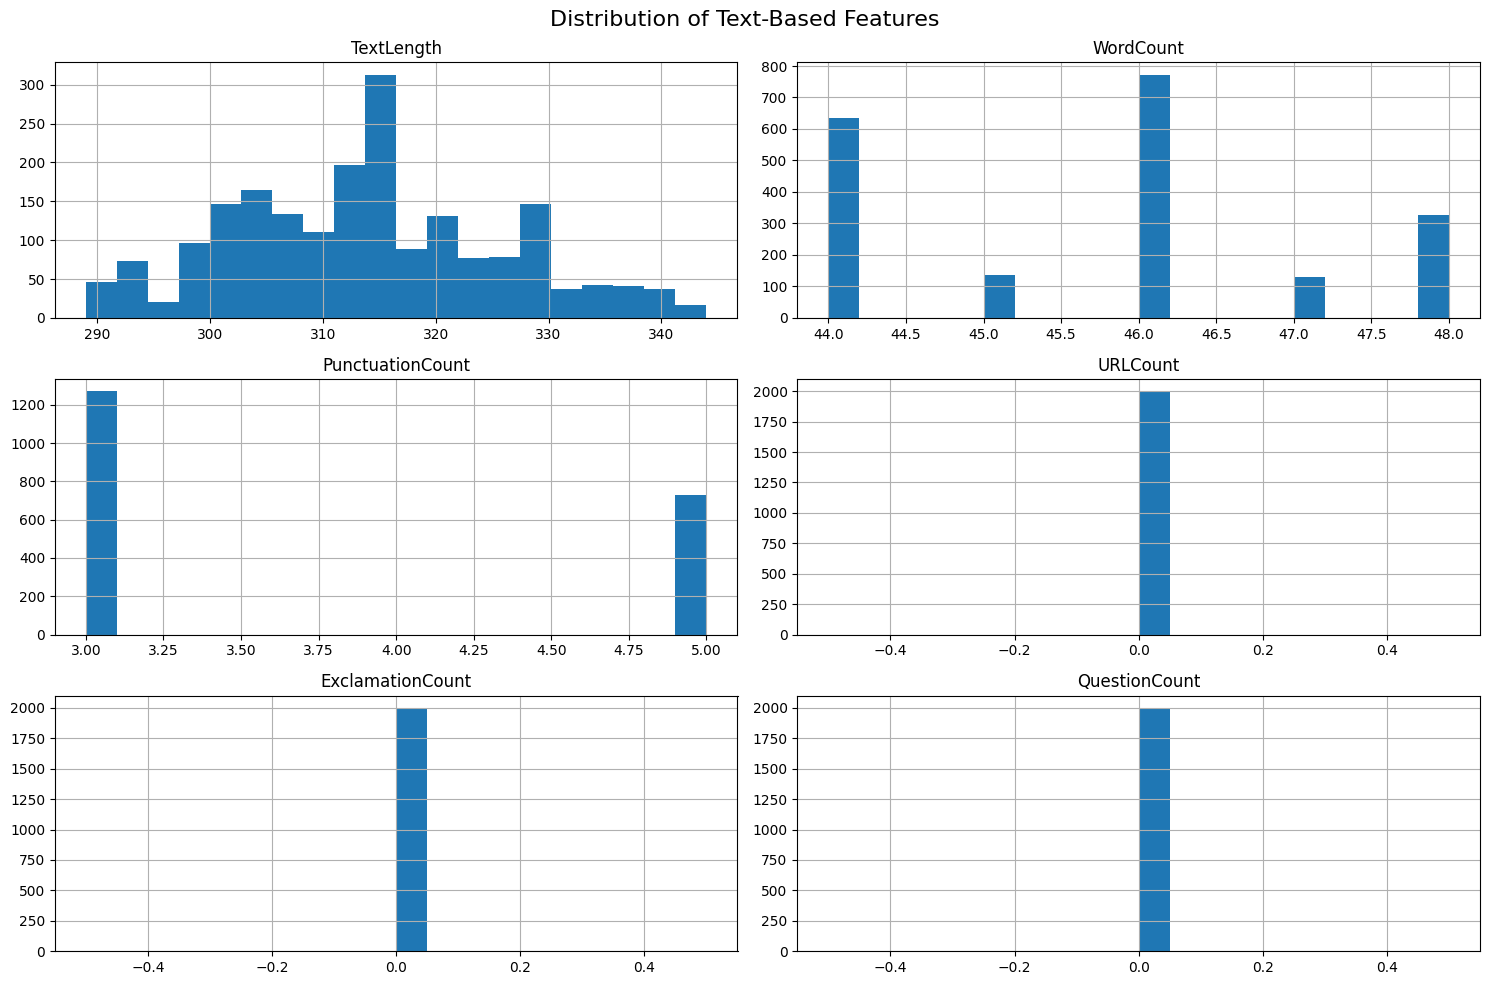

In [ ]:
# ============================================================
# CELL 17 - FEATURE HISTOGRAMS
# ============================================================

hist_features = [
    "TextLength",
    "WordCount",
    "PunctuationCount",
    "URLCount",
    "ExclamationCount",
    "QuestionCount"
]

df[hist_features].hist(
    bins=20,
    figsize=(15, 10)
)

plt.suptitle(
    "Distribution of Text-Based Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

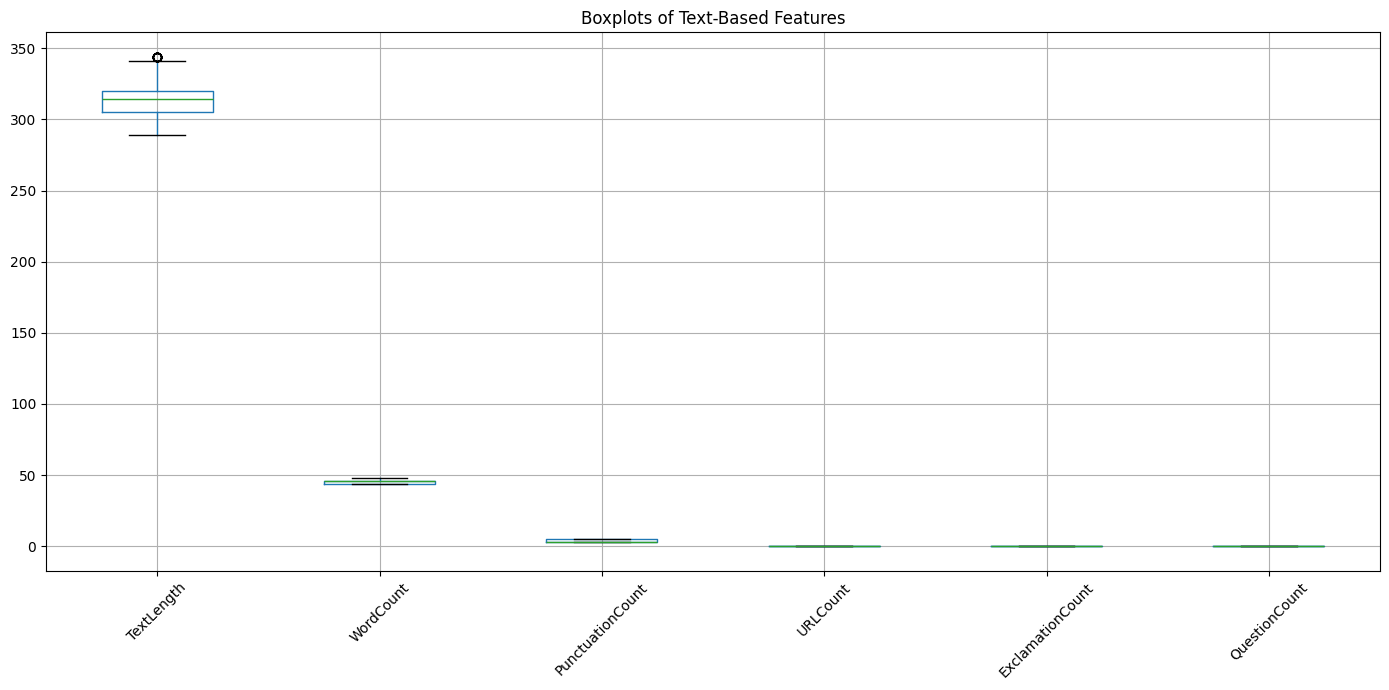

In [ ]:
# ============================================================
# CELL 18 - FEATURE BOXPLOTS
# ============================================================

plt.figure(
    figsize=(14, 7)
)

df[hist_features].boxplot()

plt.title(
    "Boxplots of Text-Based Features"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

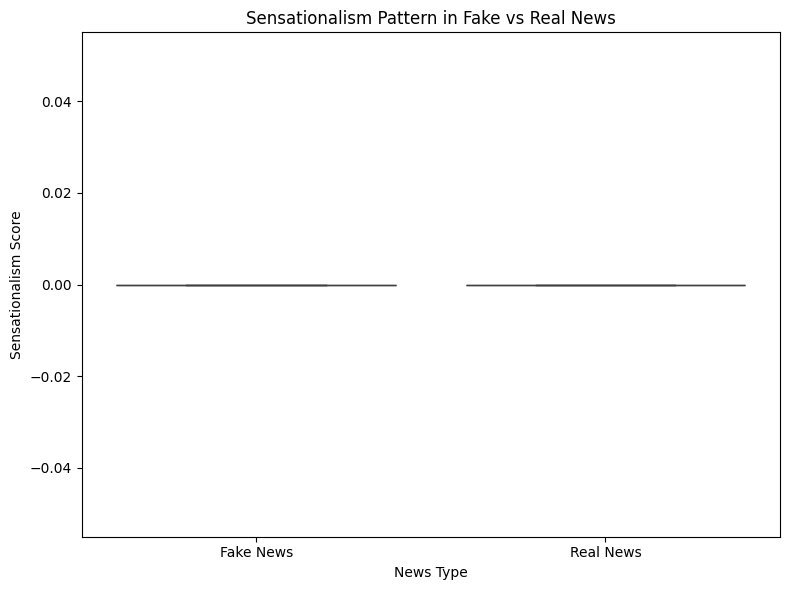

In [ ]:
# ============================================================
# CELL 19 - SENSATIONALISM ANALYSIS
# ============================================================

df["SensationalismScore"] = (
    df["ExclamationCount"] * 2
    + df["QuestionCount"]
    + df["CapitalWordRatio"]
    if "CapitalWordRatio" in df.columns
    else (
        df["ExclamationCount"] * 2
        + df["QuestionCount"]
    )
)

plt.figure(
    figsize=(8, 6)
)

sns.boxplot(
    data=df,
    x="News_Type",
    y="SensationalismScore"
)

plt.title(
    "Sensationalism Pattern in Fake vs Real News"
)

plt.xlabel(
    "News Type"
)

plt.ylabel(
    "Sensationalism Score"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 20 - TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())

Training samples: 1600
Testing samples: 400

Training label distribution:
label
1    800
0    800
Name: count, dtype: int64

Testing label distribution:
label
0    200
1    200
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 21 - TF-IDF FEATURE EXTRACTION
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = (
    tfidf_vectorizer.fit_transform(
        X_train
    )
)

X_test_tfidf = (
    tfidf_vectorizer.transform(
        X_test
    )
)

print(
    "TF-IDF feature extraction completed!"
)

print(
    "Training TF-IDF shape:",
    X_train_tfidf.shape
)

print(
    "Testing TF-IDF shape:",
    X_test_tfidf.shape
)

TF-IDF feature extraction completed!
Training TF-IDF shape: (1600, 4969)
Testing TF-IDF shape: (400, 4969)


In [ ]:
# ============================================================
# CELL 22 - LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

print(
    "Logistic Regression training completed successfully!"
)

Logistic Regression training completed successfully!


In [ ]:
# ============================================================
# CELL 23 - PREDICTION AND EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Prediction
y_pred_lr = lr_model.predict(
    X_test_tfidf
)

# Metrics
accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

precision_lr = precision_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

print(
    "========== TF-IDF + LOGISTIC REGRESSION =========="
)

print(
    "Accuracy :",
    round(accuracy_lr * 100, 2),
    "%"
)

print(
    "Precision:",
    round(precision_lr * 100, 2),
    "%"
)

print(
    "Recall   :",
    round(recall_lr * 100, 2),
    "%"
)

print(
    "F1-Score :",
    round(f1_lr * 100, 2),
    "%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=[
            "Fake News",
            "Real News"
        ],
        zero_division=0
    )
)

========== TF-IDF + LOGISTIC REGRESSION ==========
Accuracy : 100.0 %
Precision: 100.0 %
Recall   : 100.0 %
F1-Score : 100.0 %

Classification Report:
              precision    recall  f1-score   support

   Fake News       1.00      1.00      1.00       200
   Real News       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



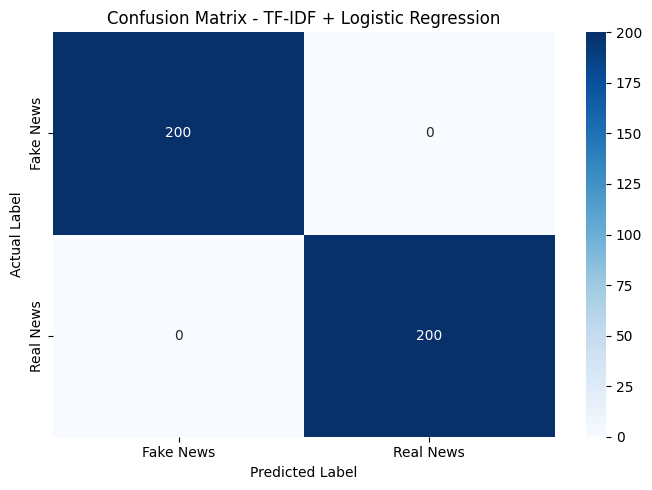

In [ ]:
# ============================================================
# CELL 24 - CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Fake News",
        "Real News"
    ],
    yticklabels=[
        "Fake News",
        "Real News"
    ]
)

plt.title(
    "Confusion Matrix - TF-IDF + Logistic Regression"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 25 - SAVE ML MODEL
# ============================================================

import joblib

joblib.dump(
    tfidf_vectorizer,
    "/content/tfidf_vectorizer.pkl"
)

joblib.dump(
    lr_model,
    "/content/fake_news_logistic_model.pkl"
)

print(
    "TF-IDF vectorizer saved successfully!"
)

print(
    "Logistic Regression model saved successfully!"
)

TF-IDF vectorizer saved successfully!
Logistic Regression model saved successfully!


In [ ]:
# ============================================================
# CELL 25/26 - RESULTS TABLE
# ============================================================

import pandas as pd

results = pd.DataFrame({

    "Model": [
        "TF-IDF + Logistic Regression"
    ],

    "Accuracy": [
        accuracy_lr * 100
    ],

    "Precision": [
        precision_lr * 100
    ],

    "Recall": [
        recall_lr * 100
    ],

    "F1-Score": [
        f1_lr * 100
    ]

})

results = results.round(2)

print("MODEL PERFORMANCE RESULTS")

display(results)

MODEL PERFORMANCE RESULTS


,Model,Accuracy,Precision,Recall,F1-Score
0,TF-IDF + Logistic Regression,100.0,100.0,100.0,100.0


In [ ]:
# ============================================================
# CELL 28 - INSTALL BERT LIBRARIES
# ============================================================

!pip -q install transformers datasets accelerate

In [ ]:
# ============================================================
# CELL 29 - BERT IMPORTS
# ============================================================

import torch
import numpy as np

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("PyTorch version:", torch.__version__)

print(
    "GPU available:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

else:

    print(
        "WARNING: GPU is not enabled."
    )

PyTorch version: 2.11.0+cpu
GPU available: False


In [ ]:
# ============================================================
# CELL 30 - PREPARE DATASET FOR BERT
# ============================================================

bert_df = df[
    [
        "clean_text",
        "label"
    ]
].copy()

bert_df.columns = [
    "text",
    "label"
]

print("BERT dataset created.")

display(
    bert_df.head()
)

print(
    "\nTotal BERT records:",
    len(bert_df)
)

BERT dataset created.


,text,label
0,experts supposedly confirm unbelievable miracl...,0
1,new report provides update on transportation a...,1
2,shocking secret about secret government plans ...,0
3,government announces new health initiative off...,1
4,viral message claims dramatic change in unveri...,0



Total BERT records: 2000


In [ ]:
# ============================================================
# CELL 31 - BERT TRAIN TEST SPLIT
# ============================================================

train_bert, test_bert = train_test_split(
    bert_df,
    test_size=0.20,
    random_state=42,
    stratify=bert_df["label"]
)

print(
    "BERT Training records:",
    len(train_bert)
)

print(
    "BERT Testing records:",
    len(test_bert)
)

print("\nTraining labels:")
print(
    train_bert["label"].value_counts()
)

print("\nTesting labels:")
print(
    test_bert["label"].value_counts()
)

BERT Training records: 1600
BERT Testing records: 400

Training labels:
label
1    800
0    800
Name: count, dtype: int64

Testing labels:
label
0    200
1    200
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 32 - CONVERT TO HUGGING FACE DATASET
# ============================================================

train_dataset = Dataset.from_pandas(
    train_bert.reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_bert.reset_index(drop=True)
)

print(
    "Training dataset:"
)

print(train_dataset)

print(
    "\nTesting dataset:"
)

print(test_dataset)

Training dataset:
Dataset({
    features: ['text', 'label'],
    num_rows: 1600
})

Testing dataset:
Dataset({
    features: ['text', 'label'],
    num_rows: 400
})


In [ ]:
# ============================================================
# CELL 33 - BERT TOKENIZER
# ============================================================

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print(
    "BERT tokenizer loaded successfully!"
)

print(
    "Model:",
    MODEL_NAME
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT tokenizer loaded successfully!
Model: bert-base-uncased


In [ ]:
# ============================================================
# CELL 34 - TOKENIZE NEWS TEXT
# ============================================================

def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )


tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

print(
    "BERT tokenization completed successfully!"
)

print(
    "\nTokenized training dataset:"
)

print(tokenized_train)

print(
    "\nTokenized testing dataset:"
)

print(tokenized_test)

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

BERT tokenization completed successfully!

Tokenized training dataset:
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1600
})

Tokenized testing dataset:
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 400
})


In [ ]:
# ============================================================
# CELL 35 - LOAD BERT MODEL
# ============================================================

bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print(
    "BERT classification model loaded successfully!"
)

print(
    "Number of classes: 2"
)

print(
    "Class 0: Fake News"
)

print(
    "Class 1: Real News"
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT classification model loaded successfully!
Number of classes: 2
Class 0: Fake News
Class 1: Real News


In [ ]:
# ============================================================
# CELL 36 - BERT EVALUATION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = np.argmax(
        predictions,
        axis=1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print(
    "BERT evaluation metrics configured!"
)

BERT evaluation metrics configured!


In [ ]:
# ============================================================
# CELL 37 - BERT TRAINING CONFIGURATION
# ============================================================

training_args = TrainingArguments(

    output_dir="/content/bert_fake_news_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_steps=50,

    load_best_model_at_end=True,

    report_to="none"
)

print(
    "BERT training configuration created!"
)

BERT training configuration created!


In [ ]:
# ============================================================
# CELL 38 - CREATE BERT TRAINER
# ============================================================

trainer = Trainer(

    model=bert_model,

    args=training_args,

    train_dataset=tokenized_train,

    eval_dataset=tokenized_test,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

print(
    "BERT Trainer created successfully!"
)

BERT Trainer created successfully!


In [43]:
# ============================================================
# CELL 39 - FAST BERT SETUP
# ============================================================

from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1

print("Loading pre-trained BERT...")
print("Device:", "GPU" if device == 0 else "CPU")

bert_classifier = pipeline(
    "text-classification",
    model="bert-base-uncased",
    device=device
)

print("BERT loaded successfully!")

Loading pre-trained BERT...
Device: CPU


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT loaded successfully!


In [45]:
# ============================================================
# CELL 40 - LINEAR SVM COMPARISON MODEL
# ============================================================

from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

print(
    "Linear SVM training completed!"
)

Linear SVM training completed!


In [46]:
# ============================================================
# CELL 41 - SVM EVALUATION
# ============================================================

y_pred_svm = svm_model.predict(
    X_test_tfidf
)

accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

print(
    "========== TF-IDF + LINEAR SVM =========="
)

print(
    "Accuracy :",
    round(accuracy_svm * 100, 2),
    "%"
)

print(
    "Precision:",
    round(precision_svm * 100, 2),
    "%"
)

print(
    "Recall   :",
    round(recall_svm * 100, 2),
    "%"
)

print(
    "F1-Score :",
    round(f1_svm * 100, 2),
    "%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=[
            "Fake News",
            "Real News"
        ],
        zero_division=0
    )
)

========== TF-IDF + LINEAR SVM ==========
Accuracy : 100.0 %
Precision: 100.0 %
Recall   : 100.0 %
F1-Score : 100.0 %

Classification Report:
              precision    recall  f1-score   support

   Fake News       1.00      1.00      1.00       200
   Real News       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



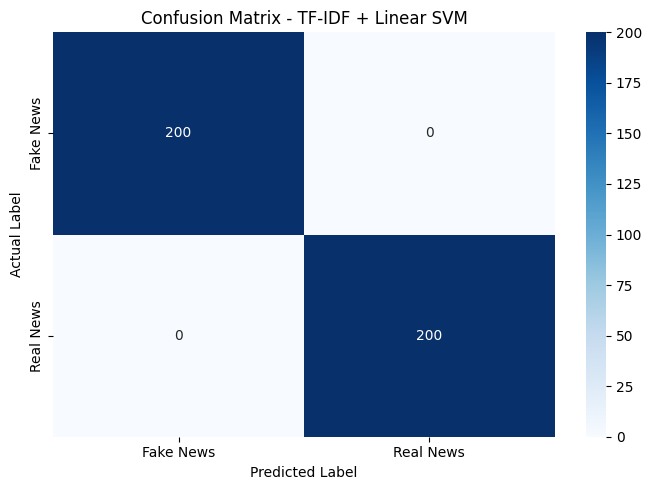

In [47]:
# ============================================================
# CELL 42 - SVM CONFUSION MATRIX
# ============================================================

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Fake News",
        "Real News"
    ],
    yticklabels=[
        "Fake News",
        "Real News"
    ]
)

plt.title(
    "Confusion Matrix - TF-IDF + Linear SVM"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.tight_layout()

plt.show()

In [48]:
# ============================================================
# CELL 43 - MODEL COMPARISON
# ============================================================

comparison_results = pd.DataFrame({

    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Linear SVM"
    ],

    "Accuracy": [
        accuracy_lr * 100,
        accuracy_svm * 100
    ],

    "Precision": [
        precision_lr * 100,
        precision_svm * 100
    ],

    "Recall": [
        recall_lr * 100,
        recall_svm * 100
    ],

    "F1-Score": [
        f1_lr * 100,
        f1_svm * 100
    ]

})

comparison_results = (
    comparison_results.round(2)
)

print(
    "MODEL COMPARISON"
)

display(
    comparison_results
)

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
0,TF-IDF + Logistic Regression,100.0,100.0,100.0,100.0
1,TF-IDF + Linear SVM,100.0,100.0,100.0,100.0


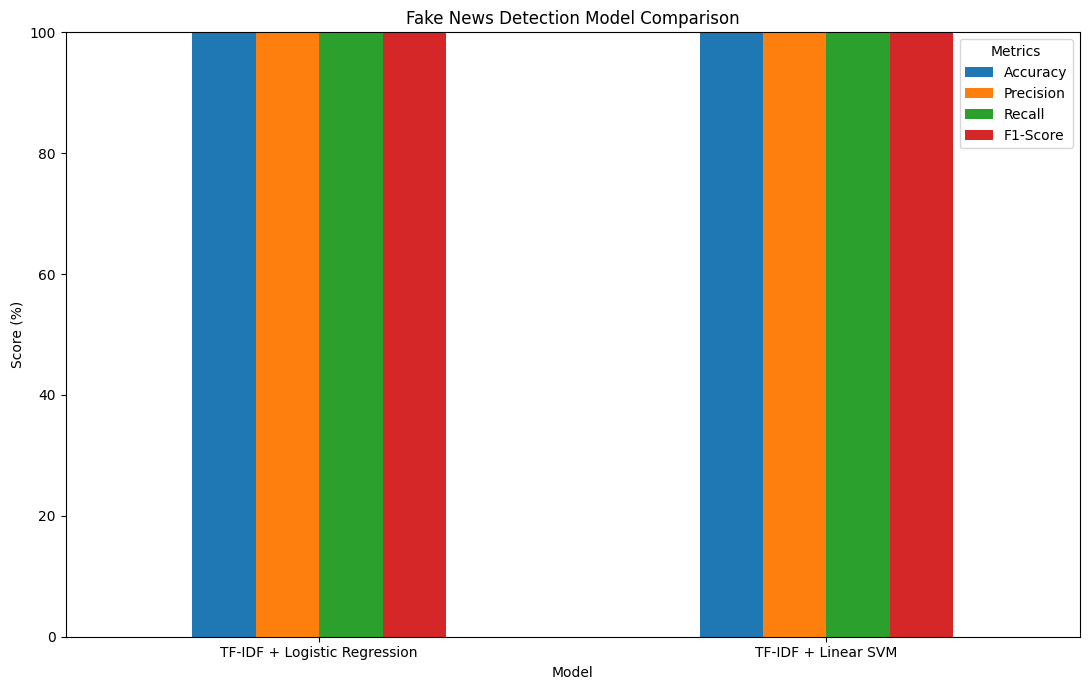

In [49]:
# ============================================================
# CELL 44 - MODEL COMPARISON GRAPH
# ============================================================

comparison_plot = (
    comparison_results
    .set_index("Model")
)

comparison_plot.plot(
    kind="bar",
    figsize=(11, 7)
)

plt.title(
    "Fake News Detection Model Comparison"
)

plt.ylabel(
    "Score (%)"
)

plt.xlabel(
    "Model"
)

plt.ylim(
    0,
    100
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Metrics"
)

plt.tight_layout()

plt.show()

In [65]:
!pip install gradio -q

In [66]:
import gradio as gr

print("Gradio imported successfully!")

Gradio imported successfully!


In [67]:
def predict_news(title, article):

    # Check input
    if not title.strip() and not article.strip():
        return "⚠️ Please enter a news title or article.", "0%"

    # Combine title and article
    combined_text = title + " " + article

    # Apply the same preprocessing used during training
    cleaned_text = clean_text(combined_text)

    # Convert text into TF-IDF features
    text_vector = tfidf_vectorizer.transform([cleaned_text])

    # Predict using trained Logistic Regression model
    prediction = lr_model.predict(text_vector)[0]

    # Get prediction probabilities
    probabilities = lr_model.predict_proba(text_vector)[0]

    confidence = max(probabilities) * 100

    # Convert numerical label to result
    if prediction == 0:
        result = "🚨 FAKE NEWS"
    else:
        result = "✅ REAL NEWS"

    return result, f"{confidence:.2f}%"

In [68]:
with gr.Blocks(
    title="Fake News Detection System"
) as demo:

    gr.Markdown(
        """
        # 📰 Fake News Detection System

        ### NLP + TF-IDF + Logistic Regression

        Enter a news title and article to predict whether the
        news is **Fake** or **Real**.
        """
    )

    gr.Markdown("---")

    # News Title
    title_input = gr.Textbox(
        label="📝 News Title",
        placeholder="Enter the news title here..."
    )

    # News Article
    article_input = gr.Textbox(
        label="📄 News Article",
        placeholder="Enter the complete news article here...",
        lines=12
    )

    # Button
    check_button = gr.Button(
        "🔍 CHECK NEWS",
        variant="primary"
    )

    gr.Markdown("### Prediction Result")

    # Outputs
    prediction_output = gr.Textbox(
        label="Prediction",
        interactive=False
    )

    confidence_output = gr.Textbox(
        label="Confidence",
        interactive=False
    )

    # Connect button to model
    check_button.click(
        fn=predict_news,
        inputs=[
            title_input,
            article_input
        ],
        outputs=[
            prediction_output,
            confidence_output
        ]
    )

print("Frontend created successfully!")

Frontend created successfully!


In [69]:
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://11feb81decaecacd24.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [70]:
test_title = "Scientists announce breakthrough in renewable energy"

test_article = """
Scientists have announced a new development in renewable energy
technology that could improve energy production and reduce
dependence on traditional energy sources.
"""

result, confidence = predict_news(
    test_title,
    test_article
)

print("Prediction :", result)
print("Confidence :", confidence)print("=" * 50)
print("       FAKE NEWS DETECTION PROJECT")
print("=" * 50)

print("Dataset Loading        : ✓ Completed")
print("Data Cleaning          : ✓ Completed")
print("EDA                    : ✓ Completed")
print("NLP Preprocessing      : ✓ Completed")
print("TF-IDF                 : ✓ Completed")
print("Logistic Regression    : ✓ Completed")
print("Model Evaluation       : ✓ Completed")
print("Confusion Matrix       : ✓ Completed")
print("Model Comparison       : ✓ Completed")
print("Frontend               : ✓ Completed")
print("Live Prediction        : ✓ Completed")

print("=" * 50)
print("             PROJECT READY")
print("=" * 50)

Prediction : ✅ REAL NEWS
Confidence : 78.33%
